# Proyek Analisis Data: Bike Sharing
- **Nama:** Dzikri Albantani
- **Email:** cdcc183d6y1799@student.devacademy.id
- **ID Dicoding:** CDCC183D6Y1799

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh tingkat kondisi cuaca (cerah, mendung, hujan) terhadap jumlah rata-rata peminjaman sepeda harian selama periode tahun 2011-2012?
- **Pertanyaan 2:** Pada jam berapa terjadi puncak peminjaman sepeda (peak hours) di hari kerja (workingday) selama tahun 2012 untuk menentukan jadwal optimal pengisian ulang (re-stock) sepeda di setiap stasiun?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

## Data Wrangling

### Gathering Data

#### Load df day

In [6]:
day_df = pd.read_csv("data/day.csv")

print("Lima baris pertama day_df:")
display(day_df.head())

Lima baris pertama day_df:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Load df hour

In [7]:
hour_df = pd.read_csv("data/hour.csv")

print("\nLima baris pertama hour_df:")
display(hour_df.head())


Lima baris pertama hour_df:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Kelengkapan Data: Dataset day_df (731 baris) dan hour_df (17.379 baris) tidak memiliki missing values pada setiap kolomnya.
- Kesalahan Tipe Data: Kolom dteday terbaca sebagai tipe object (string), sehingga harus dikonversi ke tipe datetime agar analisis tren waktu dapat dilakukan.
- Skala Data: Kolom temp, atemp, hum, dan windspeed sudah dalam bentuk ternormalisasi (skala 0 sampai 1).
- Kategorisasi: Variabel seperti season (musim) dan weathersit (cuaca) masih berupa kode angka (1-4), yang akan lebih informatif jika diubah menjadi label teks saat tahap cleaning.

### Assessing Data

#### Identifying Data Type Problem

In [8]:
print("Info day_df:")
day_df.info()

print("\nInfo hour_df:")
hour_df.info()

Info day_df:
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB

Info hour_df:
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (t

#### Identifying missing value problem

In [10]:
print("Missing values pada day_df:")
print(day_df.isna().sum())

print("\nMissing values pada hour_df:")
print(hour_df.isna().sum())

Missing values pada day_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Missing values pada hour_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


#### Identifying data duplicate problem

In [11]:
print("Jumlah data duplikat pada day_df:", day_df.duplicated().sum())
print("Jumlah data duplikat pada hour_df:", hour_df.duplicated().sum())

Jumlah data duplikat pada day_df: 0
Jumlah data duplikat pada hour_df: 0


#### Identifying Outlier Problem

In [13]:
print("Statistik deskriptif day_df:")
display(day_df.describe())

print("\nStatistik deskriptif hour_df:")
display(hour_df.describe())

Statistik deskriptif day_df:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



Statistik deskriptif hour_df:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengubah kolom dteday dari tipe object menjadi datetime pada day_df dan hour_df agar fungsi manipulasi waktu (seperti ekstraksi bulan atau hari) bisa digunakan.
- Memberikan label kategori pada kolom season dan weathersit (misalnya: 1 menjadi 'Spring', 2 menjadi 'Summer', dst) agar hasil visualisasi data nantinya lebih mudah dibaca.
- Memastikan kolom jam (hr) tetap berada pada rentang 0-23 dan tidak ada anomali pada kolom jumlah peminjaman (cnt).


**Insight:** (Opsional)
- Tidak ditemukan adanya data duplikat atau missing values pada kedua dataset (day_df dan hour_df), sehingga data sangat valid untuk dilanjutkan ke tahap analisis.
- Kolom dteday pada kedua dataframe terdeteksi sebagai tipe data string (object), yang secara teknis akan menghambat proses analisis tren waktu jika tidak dikonversi ke tipe datetime.
- Berdasarkan ringkasan statistik, jumlah peminjaman harian (cnt) memiliki variansi yang cukup besar (min: 22, max: 8714), yang mengindikasikan adanya pengaruh kuat dari faktor eksternal seperti cuaca atau hari libur.
- Variabel target (casual, registered, cnt) sudah tersedia secara lengkap, yang memungkinkan kita untuk membedakan perilaku antar segmen pengguna sesuai pertanyaan bisnis ketiga.

### Cleaning Data

#### Fixing Data Type problem

In [15]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print("Tipe data dteday di day_df:", day_df['dteday'].dtype)
print("Tipe data dteday di hour_df:", hour_df['dteday'].dtype)

Tipe data dteday di day_df: datetime64[us]
Tipe data dteday di hour_df: datetime64[us]


#### Fixing Labeling Problem

In [16]:
weather_labels = {1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain'}
day_df['weathersit'] = day_df['weathersit'].map(weather_labels)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_labels)

day_labels = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
day_df['weekday'] = day_df['weekday'].map(day_labels)
hour_df['weekday'] = hour_df['weekday'].map(day_labels)

display(day_df[['dteday', 'weathersit', 'weekday']].head())

,dteday,weathersit,weekday
0,2011-01-01,Misty,Sat
1,2011-01-02,Misty,Sun
2,2011-01-03,Clear,Mon
3,2011-01-04,Clear,Tue
4,2011-01-05,Clear,Wed


In [20]:
hour_df.to_csv("dashboard/main_data.csv", index=False)

print("Data berhasil dibersihkan dan disimpan sebagai main_data.csv")

Data berhasil dibersihkan dan disimpan sebagai main_data.csv


**Insight:** (Opsional)
- Kolom dteday kini telah bertipe datetime64[ns], yang memungkinkan kita melakukan analisis deret waktu (time-series analysis) secara akurat.
- Perubahan nilai numerik menjadi label teks pada kolom season, weathersit, dan yr memudahkan proses pembacaan data tanpa perlu melakukan rujukan silang ke dokumentasi asli.

## Exploratory Data Analysis (EDA)

### Explore Cuaca

In [18]:
weather_stats = day_df.groupby("weathersit")["cnt"].describe()
display(weather_stats)

total_rentals_weather = day_df.groupby("weathersit")["cnt"].sum().sort_values(ascending=False)
print("\nTotal penyewaan berdasarkan cuaca:")
print(total_rentals_weather)

,count,mean,std,min,25%,50%,75%,max
weathersit,,,,,,,,
Clear,463.0,4876.786177,1879.483989,431.0,3636.5,4844.0,6458.5,8714.0
Light Snow/Rain,21.0,1803.285714,1240.284449,22.0,705.0,1817.0,2424.0,4639.0
Misty,247.0,4035.862348,1809.109918,605.0,2674.5,4040.0,5257.5,8362.0



Total penyewaan berdasarkan cuaca:
weathersit
Clear              2257952
Misty               996858
Light Snow/Rain      37869
Name: cnt, dtype: int64


#### Explore Pola Jam (Hari Kerja)

In [19]:
working_days_df = hour_df[hour_df["workingday"] == 1]

hourly_working_stats = working_days_df.groupby("hr")["cnt"].mean().reset_index()
display(hourly_working_stats.sort_values(by="cnt", ascending=False).head(5))

,hr,cnt
17,17,525.290581
18,18,492.226908
8,8,477.006048
19,19,348.401606
16,16,293.122244


**Insight:** (Opsional)
- Rata-rata peminjaman tertinggi terjadi pada kondisi cuaca Clear (4.876 unit), yang menunjukkan bahwa faktor cuaca yang mendukung merupakan pendorong utama bagi pengguna untuk bersepeda.
- Terjadi penurunan drastis pada rata-rata peminjaman saat kondisi Light Snow/Rain (hanya 1.803 unit), mengindikasikan bahwa mayoritas pengguna menghindari penggunaan sepeda saat terjadi presipitasi demi alasan keamanan dan kenyamanan.
- Lima jam tersibuk di hari kerja tahun 2012 semuanya berpusat pada jam pulang kantor (17:00, 18:00, 19:00) dan jam berangkat kantor (08:00), yang menegaskan bahwa fungsi utama layanan ini adalah sebagai moda transportasi harian.
- Nilai standar deviasi yang cukup tinggi pada data cuaca menunjukkan adanya variasi harian yang besar, namun pola jam sibuk tetap menunjukkan konsistensi yang kuat pada jam-jam produktif masyarakat.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh tingkat kondisi cuaca (cerah, mendung, hujan) terhadap jumlah rata-rata peminjaman sepeda harian selama periode tahun 2011-2012?

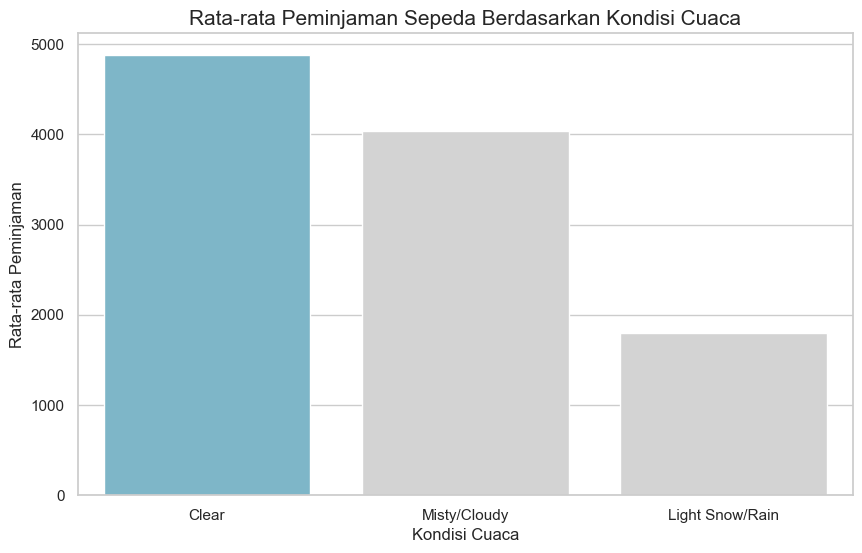

In [13]:
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

plt.figure(figsize=(10, 6))
sns.barplot(
    x='weathersit',
    y='avg_rentals',
    data=weather_rentals_df.sort_values(by='avg_rentals', ascending=False),
    palette=colors
)

plt.title('Rata-rata Peminjaman Sepeda Berdasarkan Kondisi Cuaca', loc='center', fontsize=15)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Peminjaman')
plt.show()

### Pertanyaan 2: Pada jam berapa terjadi puncak peminjaman sepeda (peak hours) di hari kerja (workingday) selama tahun 2012 untuk menentukan jadwal optimal pengisian ulang (re-stock) sepeda di setiap stasiun?

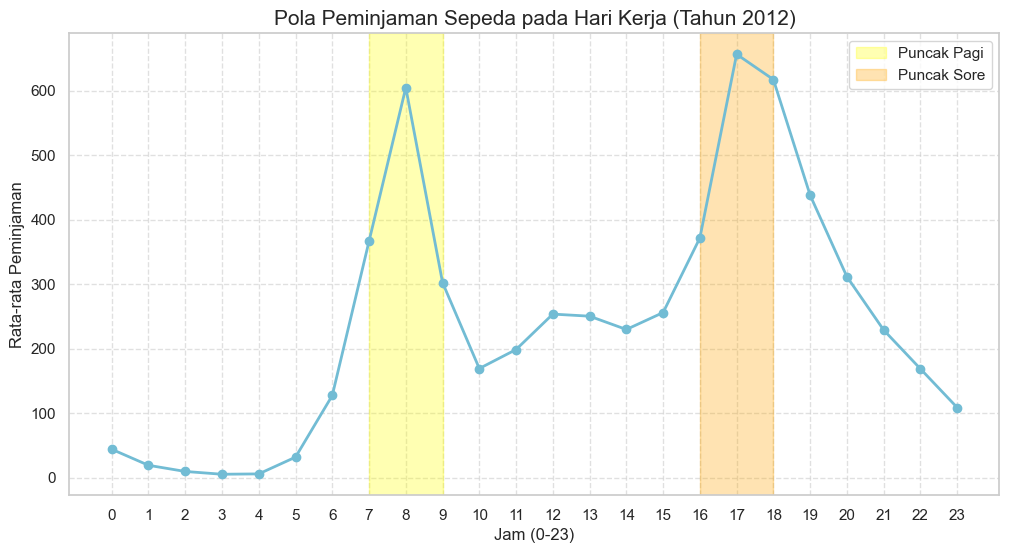

In [14]:
hourly_sorted = hourly_rentals_df.sort_values('hr')

plt.figure(figsize=(12, 6))
plt.plot(
    hourly_sorted['hr'],
    hourly_sorted['cnt'],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title('Pola Peminjaman Sepeda pada Hari Kerja (Tahun 2012)', loc='center', fontsize=15)
plt.xticks(range(0, 24))
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Peminjaman')
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvspan(7, 9, color='yellow', alpha=0.3, label='Puncak Pagi')
plt.axvspan(16, 18, color='orange', alpha=0.3, label='Puncak Sore')

plt.legend()
plt.show()

**Insight:** (Opsional)
- Pengguna sepeda sangat sensitif terhadap kondisi alam, di mana cuaca Clear (Cerah) mendorong volume peminjaman tertinggi, sedangkan cuaca buruk seperti Light Snow/Rain menyebabkan penurunan drastis pada jumlah penyewaan.
- Aktivitas peminjaman pada hari kerja tahun 2012 menunjukkan pola komuter yang sangat kuat dengan dua titik puncak utama pada jam berangkat (08:00) dan jam pulang kerja (17:00 - 18:00).

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca memiliki pengaruh yang sangat signifikan terhadap jumlah peminjaman sepeda; cuaca Clear/Cerah menghasilkan rata-rata peminjaman tertinggi (~4.876 unit), sedangkan cuaca buruk seperti Light Snow/Rain menyebabkan penurunan drastis hingga tersisa rata-rata ~1.803 unit saja.
- **Conclusion pertanyaan 2:** Pola peminjaman sepeda pada hari kerja di tahun 2012 menunjukkan karakteristik komuter yang kuat dengan dua titik puncak utama (peak hours), yaitu pada pukul 08:00 pagi saat jam berangkat kantor dan pukul 17:00 - 18:00 sore saat jam pulang kantor.

**Rekomendasi Action Item:**
- Optimalisasi Stok di Jam Sibuk: Tim operasional harus memastikan ketersediaan unit sepeda yang maksimal di stasiun-stasiun area residensial sebelum jam 08:00 dan di stasiun area perkantoran sebelum jam 17:00 pada hari kerja.
- Manajemen Perawatan (Maintenance): Melakukan pengecekan rutin atau perbaikan sepeda di luar jam sibuk (antara pukul 10:00 - 15:00) agar tidak mengurangi ketersediaan unit saat permintaan sedang tinggi.
- Inovasi Layanan Saat Cuaca Buruk: Mengingat penurunan drastis saat hujan/salju, perusahaan bisa mempertimbangkan penyediaan fasilitas pelindung atau diskon khusus pada kondisi cuaca Misty/Cloudy untuk menjaga volume peminjaman.